# Phase 2 — AION spectrum tokenizer

Phase 5 uses the **official Polymathic AION** DESI spectrum codec (frozen weights from Hugging Face `polymathic-ai/aion-base`). We do **not** train an in-repo `SpectrumCodec` anymore.

**Kernel:** `.venv/bin/python` from the repo root (`bash scripts/bootstrap_venv.sh` installs `polymathic-aion`).

**Prereqs**

1. Repo `.env` with `HF_TOKEN=...` (gated model access).
2. First encode downloads weights (~1–5 min). On NERSC, run `scripts/prefetch_aion_codec.py` on a **login node** first.

**Pipeline (per spectrum)**

1. `DR1StreamDataset` → stitched flux, ivar, mask, wavelength (variable length).
2. `collate_spectra` → padded batch.
3. `AionSpectrumTokenizer.encode_batch` → linear resample to **8704** px, then AION `CodecManager` → **`(B, 273)`** code indices in `[0, 1023]`.
4. Transformer adds `SPECTRUM_OFFSET=8` for vocabulary IDs.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

_cwd = Path.cwd().resolve()
if (_cwd / "src" / "desifm").is_dir():
    REPO = _cwd
elif (_cwd.parent / "src" / "desifm").is_dir():
    REPO = _cwd.parent
else:
    raise FileNotFoundError(f"Could not find repo root (src/desifm). cwd={_cwd}")
sys.path.insert(0, str(REPO / "src"))

try:
    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["figure.figsize"] = (12, 4)

from desifm.constants import GRID_SIZE, N_LATENT_TOKENS, N_SPECTRUM_CODES, SPECTRUM_OFFSET
from desifm.training.env import load_project_env

load_project_env()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("REPO:", REPO)
print("device:", DEVICE)
print(f"GRID_SIZE={GRID_SIZE}  N_LATENT_TOKENS={N_LATENT_TOKENS}  N_SPECTRUM_CODES={N_SPECTRUM_CODES}")


REPO: /Users/jonathansamuel/projects/cs-686-dl/final-project
device: cpu
GRID_SIZE=8704  N_LATENT_TOKENS=273  N_SPECTRUM_CODES=1024


## 1. Grid resample (8704)

AION expects a fixed-length grid. `resample_spectrum_batch` linearly interpolates flux, ivar, wavelength and nearest-neighbors the mask — same step as inside `AionSpectrumTokenizer`.


input length: 6000
resampled: (1, 8704) did_resample: True


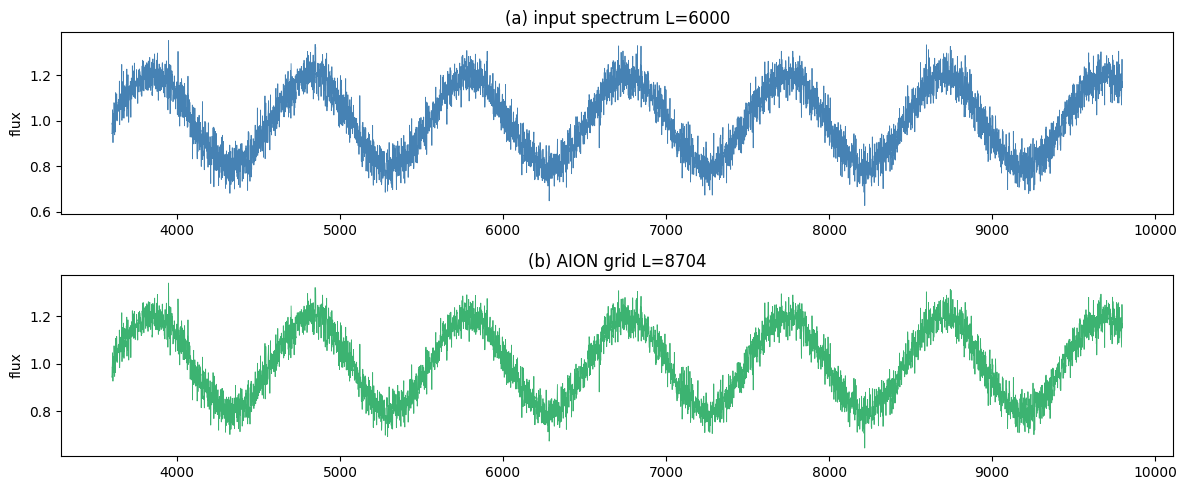

In [2]:
from desifm.data.synthetic import SyntheticSpectrumDataset
from desifm.data.dr1_stream import collate_spectra
from desifm.tokenization.aion_grid import resample_spectrum_batch

torch.manual_seed(0)
ds = SyntheticSpectrumDataset(n_spectra=1, length=6000, seed=0)
item = ds[0]
batch = collate_spectra([item])

flux = batch["flux"]
wave = batch["wavelength"]
print("input length:", flux.shape[-1])

flux_g, ivar_g, mask_g, wave_g, did = resample_spectrum_batch(
    batch["flux"], batch["ivar"], batch["mask"], batch["wavelength"], length=GRID_SIZE
)
print("resampled:", tuple(flux_g.shape), "did_resample:", did)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=False)
axes[0].plot(wave[0].numpy(), flux[0].numpy(), lw=0.6, color="steelblue")
axes[0].set_ylabel("flux")
axes[0].set_title(f"(a) input spectrum L={flux.shape[-1]}")
axes[1].plot(wave_g[0].numpy(), flux_g[0].numpy(), lw=0.6, color="mediumseagreen")
axes[1].set_ylabel("flux")
axes[1].set_title(f"(b) AION grid L={GRID_SIZE}")
plt.tight_layout()
plt.show()


## 2. Encode with AION (synthetic batch)

Creates `CodecManager` on first use. Codes are stored under the key `tok_spectrum_desi`.


In [3]:
from desifm.tokenization.aion_bridge import AionSpectrumTokenizer, AION_TOKEN_KEY

try:
    import aion  # noqa: F401
except ImportError as e:
    raise ImportError('Install AION: pip install -e ".[aion]"') from e

B = 4
items = [SyntheticSpectrumDataset(n_spectra=1, length=4000 + 500 * i, seed=i)[0] for i in range(B)]
batch = collate_spectra(items)

tok = AionSpectrumTokenizer(DEVICE)
spec_idx, meta = tok.encode_batch(batch)
print("AION token key:", AION_TOKEN_KEY)
print("codes shape:", tuple(spec_idx.shape), "meta:", meta)
print("min/max:", int(spec_idx.min()), int(spec_idx.max()))
print("unique in batch:", int(spec_idx.unique().numel()), "/", N_SPECTRUM_CODES)


/Users/jonathansamuel/projects/cs-686-dl/final-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AION token key: tok_spectrum_desi
codes shape: (4, 273) meta: {'resampled_to_grid': True, 'grid_size': 8704}
min/max: 8 1023
unique in batch: 498 / 1024


## 3. Token distribution (one batch)

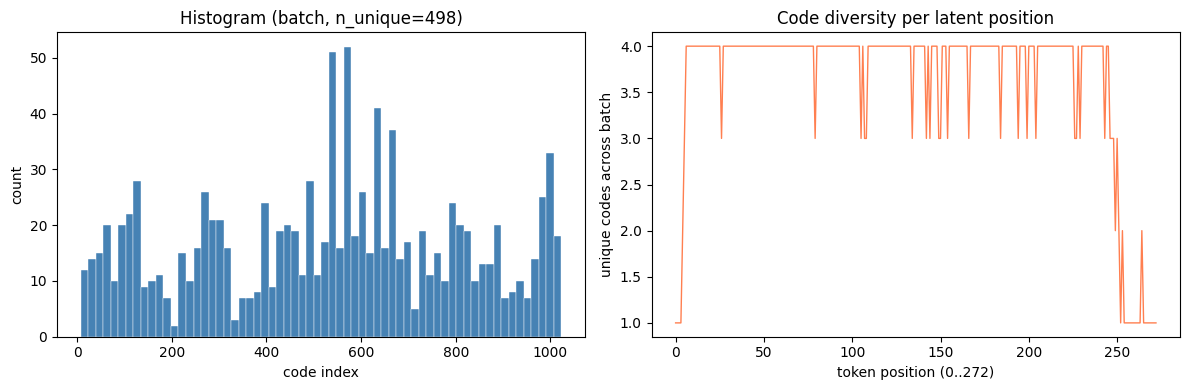

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

codes = spec_idx.cpu().numpy().ravel()
axes[0].hist(codes, bins=64, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("code index")
axes[0].set_ylabel("count")
axes[0].set_title(f"Histogram (batch, n_unique={len(np.unique(codes))})")

# Per-position diversity across batch
pos_unique = [len(np.unique(spec_idx[:, i].cpu().numpy())) for i in range(N_LATENT_TOKENS)]
axes[1].plot(pos_unique, color="coral", lw=1)
axes[1].set_xlabel("token position (0..272)")
axes[1].set_ylabel("unique codes across batch")
axes[1].set_title("Code diversity per latent position")
plt.tight_layout()
plt.show()


## 4. Token sequence for one spectrum

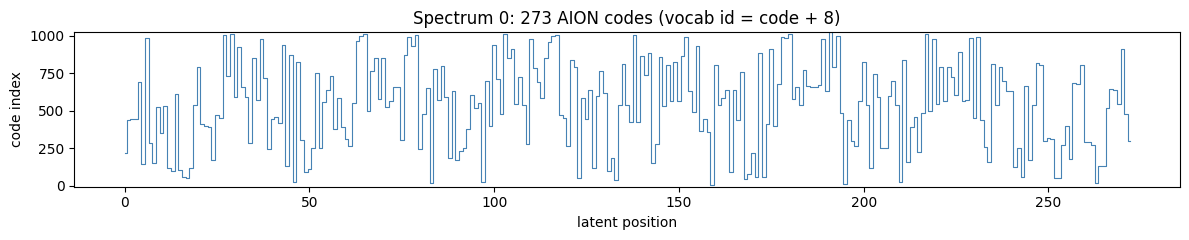

first 16 codes: [223, 442, 447, 446, 690, 147, 987, 285, 153, 527, 350, 536, 120, 103, 616, 106]
first 16 vocab ids: [231, 450, 455, 454, 698, 155, 995, 293, 161, 535, 358, 544, 128, 111, 624, 114]


In [5]:
b = 0
seq = spec_idx[b].cpu().numpy()
vocab_ids = seq + SPECTRUM_OFFSET

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.plot(seq, drawstyle="steps-mid", lw=0.8, color="steelblue")
ax.set_xlabel("latent position")
ax.set_ylabel("code index")
ax.set_title(f"Spectrum {b}: 273 AION codes (vocab id = code + {SPECTRUM_OFFSET})")
ax.set_ylim(-5, N_SPECTRUM_CODES)
plt.tight_layout()
plt.show()

print("first 16 codes:", seq[:16].tolist())
print("first 16 vocab ids:", vocab_ids[:16].tolist())


## 5. Real DR1 spectra (optional)

Run **Phase 1** first to create `data/manifests/train_eval_dr1.jsonl`, or point `MANIFEST` at your own JSONL.


DR1 batch codes: (4, 273) n_unique: 634


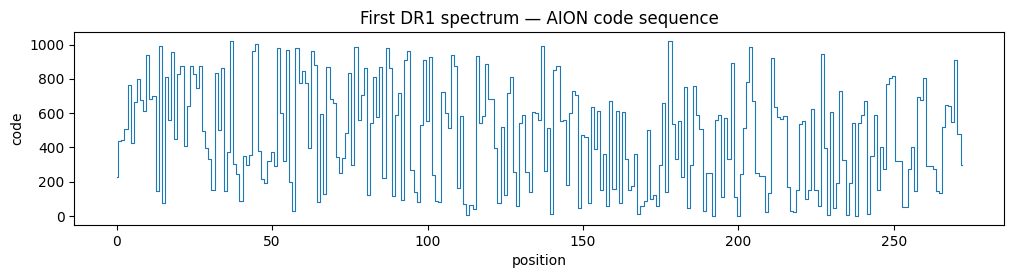

In [6]:
from desifm.data.dr1_stream import DR1StreamDataset, load_manifest

MANIFEST = REPO / "data" / "manifests" / "train_eval_dr1.jsonl"
if not MANIFEST.is_file():
    print("Skip: no manifest at", MANIFEST, "— run notebooks/01_phase_data.ipynb section 1")
else:
    records = load_manifest(MANIFEST)
    ds = DR1StreamDataset(records, max_spectra=8)
    items = []
    for i in range(len(ds)):
        it = ds[i]
        if it is not None:
            items.append(it)
        if len(items) >= 4:
            break
    batch_dr1 = collate_spectra(items)
    spec_dr1, meta_dr1 = tok.encode_batch(batch_dr1)
    print("DR1 batch codes:", tuple(spec_dr1.shape), "n_unique:", int(spec_dr1.unique().numel()))
    fig, ax = plt.subplots(figsize=(12, 2.5))
    ax.plot(spec_dr1[0].cpu().numpy(), drawstyle="steps-mid", lw=0.8)
    ax.set_title("First DR1 spectrum — AION code sequence")
    ax.set_xlabel("position")
    ax.set_ylabel("code")
    plt.show()


## 6. Transformer training

Spectrum codes feed `scripts/train_model.py` with `--spectrum-tokenizer aion`. Redshift still uses the small in-repo `RedshiftCodec` (256 bins).

```bash
# Smoke (synthetic, no FITS)
.venv/bin/python scripts/smoke_aion_tokenizer.py --synthetic

# NERSC prefetch (login node)
.venv/bin/python scripts/prefetch_aion_codec.py
```

See `docs/NERSC_INTERACTIVE.md` for DDP commands.
